# Análise Exploratória - March Machine Learning Mania 2026

Objetivos:
- entender a estrutura dos dados;
- explorar padrões temporais e de performance;
- avaliar variáveis já usadas no pipeline;
- identificar sinais fortes para o modelo.

### Imports e configuração

In [1]:
#===================== Imports e configuração =================#
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath("../src"))

from config import GENDER, SEED
from data_loading import (
    build_all_games,
    load_seeds,
    load_teams,
    load_conferences,
    load_sample_submission,
    load_massey_ordinals,
    load_tourney_compact,
)
from elo_rating import compute_elo_ratings, compute_elo_per_game
from feature_engineering import (
    compute_season_stats,
    compute_tourney_history,
    compute_elo_pre_tourney,
)
from dataset_builder import build_training_matchups, get_feature_columns
from validation import evaluate_predictions

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
np.random.seed(SEED)

###  Carregamento dos dados

In [2]:
games = build_all_games()
seeds = load_seeds()
teams = load_teams()
conferences = load_conferences()
tourney = load_tourney_compact()
sample_sub = load_sample_submission(stage=2)

print("games:", games.shape)
print("seeds:", seeds.shape)
print("teams:", teams.shape)
print("conferences:", conferences.shape)
print("tourney:", tourney.shape)
print("sample_sub:", sample_sub.shape)
games.info()

games: (125978, 35)
seeds: (2694, 4)
teams: (381, 4)
conferences: (13753, 3)
tourney: (2585, 8)
sample_sub: (132133, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125978 entries, 0 to 125977
Data columns (total 35 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   WDR        125978 non-null  int64 
 1   WTO        125978 non-null  int64 
 2   DayNum     125978 non-null  int64 
 3   LBlk       125978 non-null  int64 
 4   LFGM       125978 non-null  int64 
 5   WFGA       125978 non-null  int64 
 6   LFTM       125978 non-null  int64 
 7   WPF        125978 non-null  int64 
 8   LTeamID    125978 non-null  int64 
 9   LFGA3      125978 non-null  int64 
 10  WOR        125978 non-null  int64 
 11  LTO        125978 non-null  int64 
 12  WFGA3      125978 non-null  int64 
 13  WFGM3      125978 non-null  int64 
 14  WFTM       125978 non-null  int64 
 15  WLoc       125978 non-null  object
 16  WTeamID    125978 non-null  int64 
 17  NumO

### Visão geral do dataset

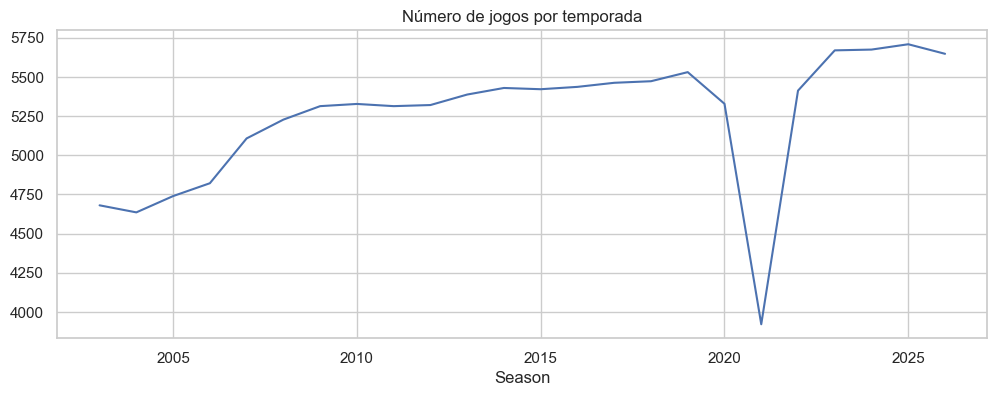

IsTourney,False,True
Season,,
2003,4616,64
2004,4571,64
2005,4675,64
2006,4757,64
2007,5043,64


In [3]:
games["IsTourney"].value_counts(normalize=True)
games.groupby("Season").size().plot(figsize=(12,4), title="Número de jogos por temporada")
plt.show()
games.groupby(["Season", "IsTourney"]).size().unstack(fill_value=0).head()

### Distribuição de pontos e diferença de placar

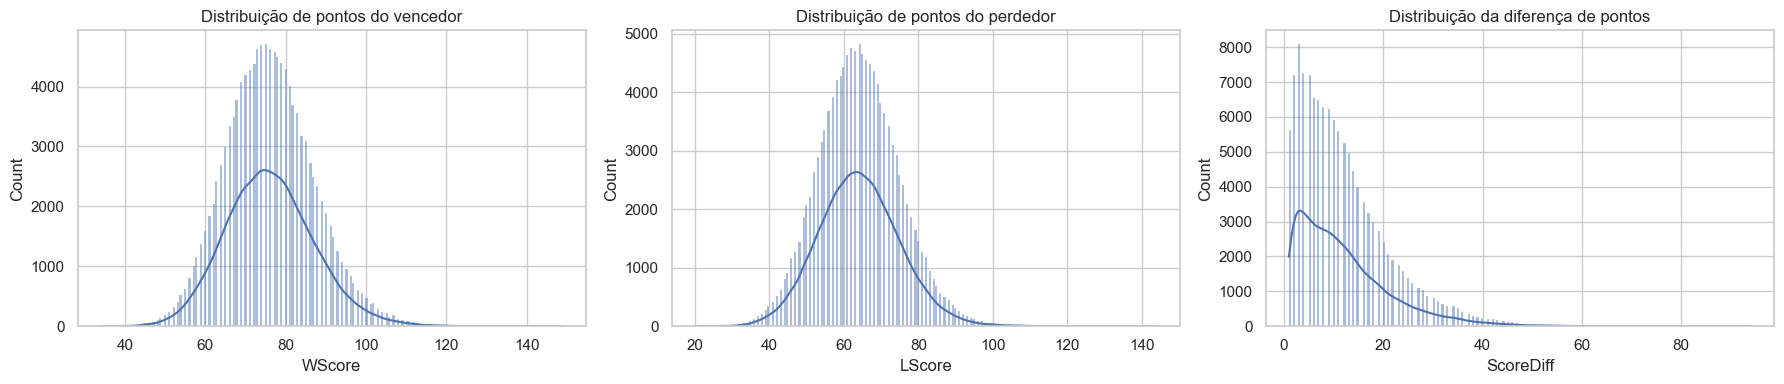

In [4]:
games["ScoreDiff"] = games["WScore"] - games["LScore"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(games["WScore"], kde=True, ax=axes[0])
axes[0].set_title("Distribuição de pontos do vencedor")

sns.histplot(games["LScore"], kde=True, ax=axes[1])
axes[1].set_title("Distribuição de pontos do perdedor")

sns.histplot(games["ScoreDiff"], kde=True, ax=axes[2])
axes[2].set_title("Distribuição da diferença de pontos")

plt.tight_layout()
plt.show()

### Home court advantage

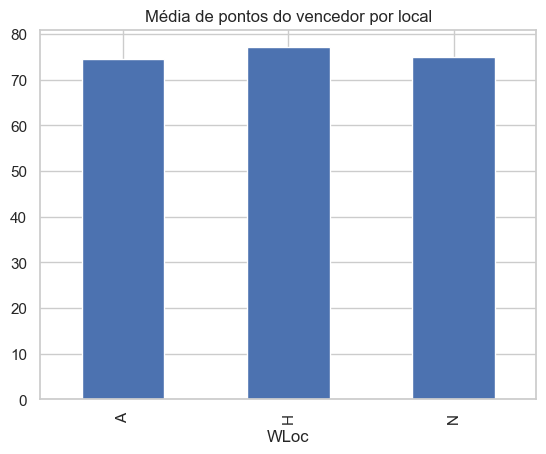

In [5]:
games["WLoc"].value_counts(dropna=False)
games.groupby("WLoc")["ScoreDiff"].mean().sort_values(ascending=False)
games.groupby("WLoc")["WScore"].mean().plot(kind="bar", title="Média de pontos do vencedor por local")
plt.show()

### Seeds: relação com desempenho

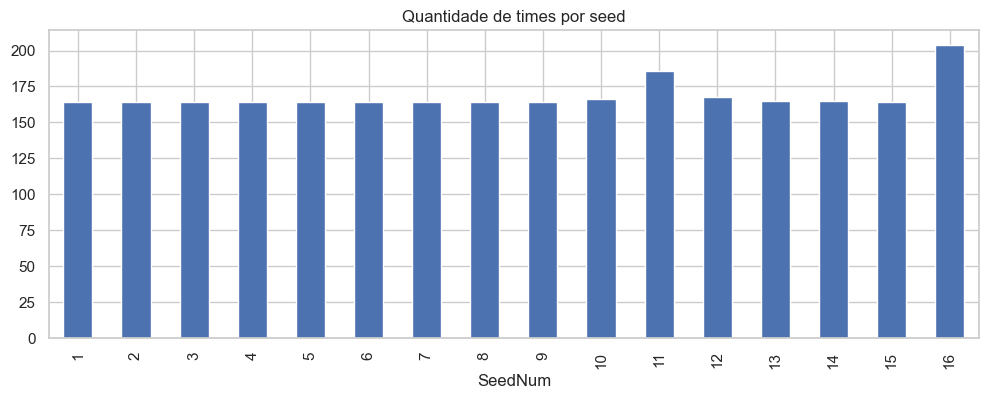

In [6]:
seed_summary = seeds.copy()
seed_summary["SeedNum"] = seed_summary["SeedNum"].astype(int)

seed_summary.groupby("SeedNum").size().plot(kind="bar", figsize=(12,4), title="Quantidade de times por seed")
plt.show()

(2585, 115)


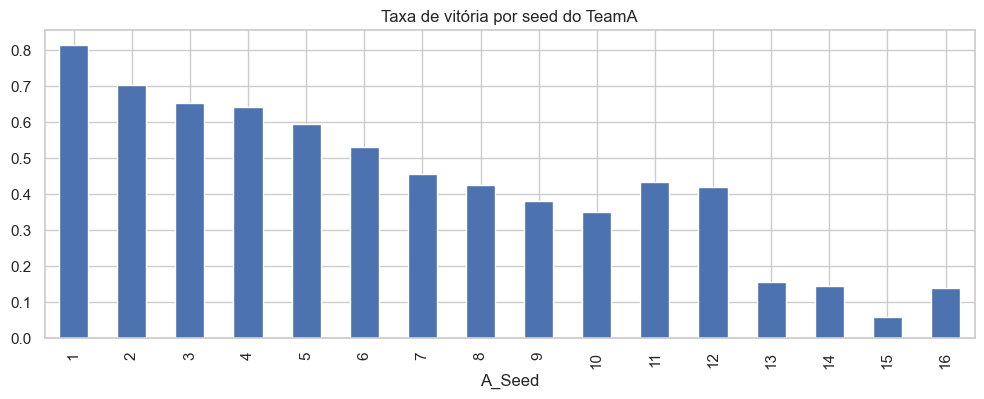

In [7]:
elo_df = compute_elo_ratings(games)
elo_per_game = compute_elo_per_game(games)
elo_pre_tourney = compute_elo_pre_tourney(elo_per_game)
team_features = compute_season_stats(games).merge(elo_pre_tourney, on=["Season", "TeamID"], how="left")
tourney_history = compute_tourney_history(tourney)

train_matchups = build_training_matchups(
    tourney=tourney,
    team_features=team_features,
    seeds=seeds,
    elo_df=elo_df,
    tourney_history=tourney_history,
)
print(train_matchups.shape)


train_matchups["Result"].mean()
train_matchups.groupby("A_Seed")["Result"].mean().sort_index().plot(kind="bar", figsize=(12,4), title="Taxa de vitória por seed do TeamA")
plt.show()

###  ELO: distribuição e separação por resultado

In [8]:
elo_df["ELO"].describe()

count    8445.000000
mean     1500.000000
std       185.634722
min       926.629552
25%      1367.618555
50%      1493.326680
75%      1628.300882
max      2090.078537
Name: ELO, dtype: float64

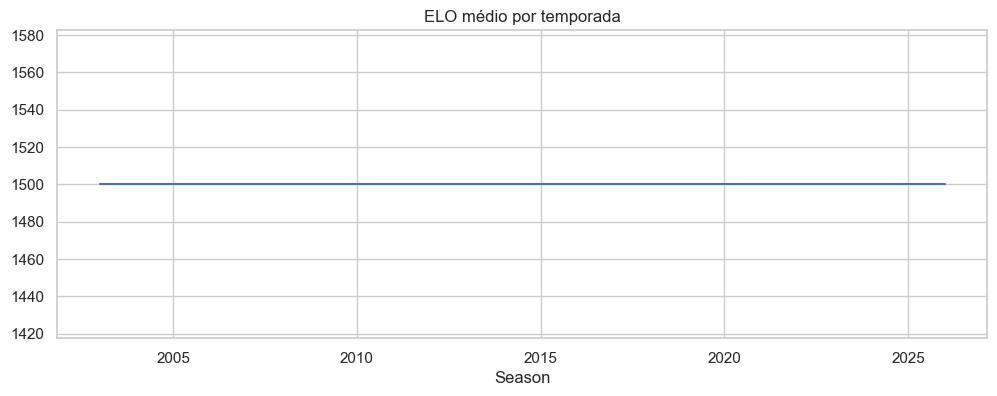

In [9]:
elo_df.groupby("Season")["ELO"].mean().plot(figsize=(12,4), title="ELO médio por temporada")
plt.show()

In [10]:
train_matchups["Diff_ELO"].describe()

count    2585.000000
mean        0.511834
std       131.213623
min      -564.582844
25%       -20.471109
50%         0.000000
75%        18.427321
max       598.270722
Name: Diff_ELO, dtype: float64

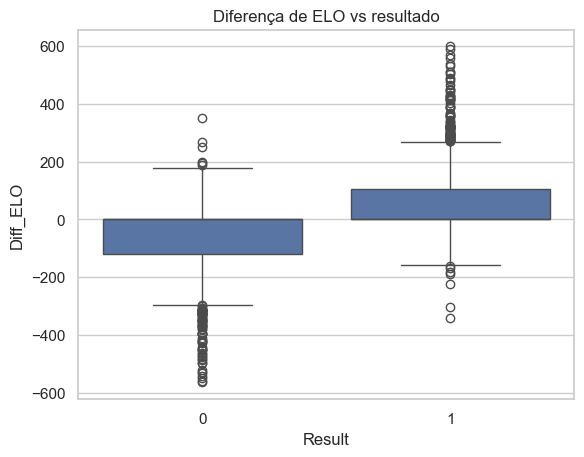

In [11]:
sns.boxplot(data=train_matchups, x="Result", y="Diff_ELO")
plt.title("Diferença de ELO vs resultado")
plt.show()

### Estatísticas por time/temporada

In [12]:
team_features = compute_season_stats(games)
team_features.head()

,Season,TeamID,Wins,Games,Score_mean,OppScore_mean,ScoreDiff_mean,OffEff_mean,DefEff_mean,FGM_mean,FGA_mean,FGM3_mean,FGA3_mean,FTM_mean,FTA_mean,OR_mean,DR_mean,Ast_mean,TO_mean,Stl_mean,Blk_mean,PF_mean,Poss_mean,WinPct,AvgScoreDiff,FGPct,FG3Pct,FTPct,AstTO,NetEff,Rolling_WinPct,Rolling_ScoreDiff,Rolling_Score,SOS,AdjOffEff
0,2003,1102,12,28,57.250000,57.000000,0.250000,103.835749,103.601436,19.142857,39.785714,7.821429,20.821429,11.142857,17.107143,4.178571,16.821429,13.000000,11.428571,5.964286,1.785714,18.750000,55.045536,0.428571,0.250000,0.481149,0.375643,0.651357,1.137500,0.234313,0.214286,-6.428571,54.000000,0.530644,106.842749
1,2003,1103,13,27,78.777778,78.148148,0.629630,110.667469,110.408760,27.148148,55.851852,5.444444,16.074074,19.037037,25.851852,9.777778,19.925926,15.222222,12.629630,7.259259,2.333333,19.851852,70.900000,0.481481,0.629630,0.486074,0.338710,0.736390,1.205279,0.258709,0.500000,0.000000,75.928571,0.489779,113.617466
2,2003,1104,17,28,69.285714,65.000000,4.285714,103.557697,97.794103,24.035714,57.178571,6.357143,19.857143,14.857143,20.928571,13.571429,23.928571,12.107143,13.285714,6.607143,3.785714,18.035714,66.720536,0.607143,4.285714,0.420362,0.320144,0.709898,0.911290,5.763594,0.357143,-1.785714,68.214286,0.572492,106.780731
3,2003,1105,7,26,71.769231,76.653846,-4.884615,93.616492,100.207433,24.384615,61.615385,7.576923,20.769231,15.423077,21.846154,13.500000,23.115385,14.538462,18.653846,9.307692,2.076923,20.230769,76.680288,0.269231,-4.884615,0.395755,0.364815,0.705986,0.779381,-6.590941,0.214286,-1.857143,73.714286,0.415228,88.889618
4,2003,1106,13,28,63.607143,63.750000,-0.142857,93.773763,94.224204,23.428571,55.285714,6.107143,17.642857,10.642857,16.464286,12.285714,23.857143,11.678571,17.035714,8.357143,3.142857,18.178571,67.716071,0.464286,-0.142857,0.423773,0.346154,0.646421,0.685535,-0.450441,0.428571,2.357143,63.571429,0.458062,91.874600


In [13]:
team_features.select_dtypes(include=[np.number]).describe().T.sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Season,8346.0,2014.702013,6.907589,2003.000000,2009.000000,2015.000000,2021.000000,2026.000000
TeamID,8346.0,1285.877067,105.410156,1101.000000,1194.000000,1285.000000,1378.000000,1481.000000
AdjOffEff,8346.0,104.100668,8.564849,71.785314,98.491550,104.130870,109.758114,137.715804
DefEff_mean,8346.0,102.319093,5.633897,83.201102,98.469776,102.281154,106.142599,124.221934
OffEff_mean,8346.0,102.012423,6.687693,74.438284,97.623838,102.137651,106.531816,123.992706
OppScore_mean,8346.0,70.221948,5.562822,50.428571,66.500000,70.142857,73.870968,98.206897
Score_mean,8346.0,70.009578,5.889036,49.240000,66.032258,69.967742,73.895628,95.551724
Rolling_Score,8346.0,69.823414,6.138955,46.857143,65.642857,69.714286,73.928571,98.500000
Poss_mean,8346.0,68.633116,3.347812,54.460268,66.459399,68.660212,70.826840,91.060345
FGA_mean,8346.0,56.357893,3.513006,39.785714,54.111111,56.426407,58.620690,78.620690


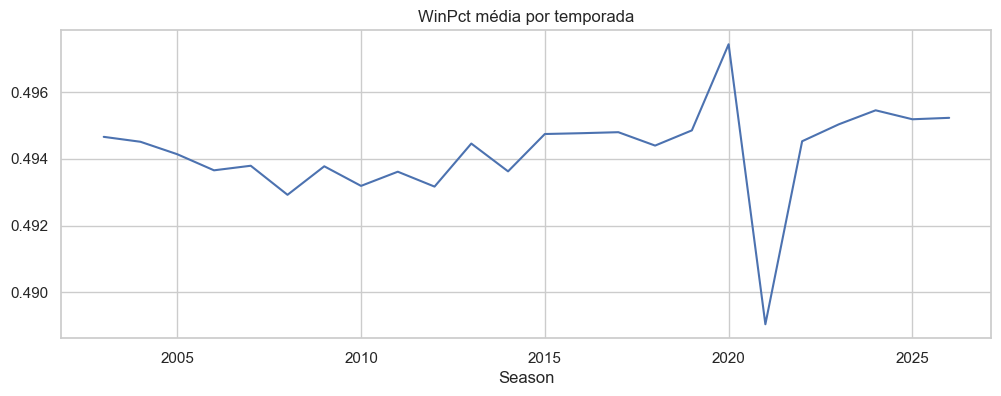

In [14]:
team_features.groupby("Season")["WinPct"].mean().plot(figsize=(12,4), title="WinPct média por temporada")
plt.show()

In [15]:

cols = ["Rolling_WinPct", "Rolling_ScoreDiff", "Rolling_Score"]
team_features[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Rolling_WinPct,8346.0,0.492769,0.213326,0.000000,0.357143,0.500000,0.642857,1.000000
Rolling_ScoreDiff,8346.0,-0.254556,6.453137,-33.222222,-4.500000,-0.214286,4.000000,25.142857
Rolling_Score,8346.0,69.823414,6.138955,46.857143,65.642857,69.714286,73.928571,98.500000


### Strength of Schedule e eficiênci

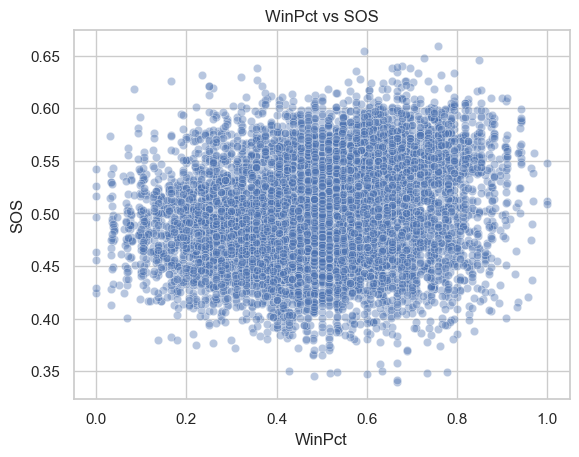

In [16]:
if "SOS" in team_features.columns:
    sns.scatterplot(data=team_features, x="WinPct", y="SOS", alpha=0.4)
    plt.title("WinPct vs SOS")
    plt.show()

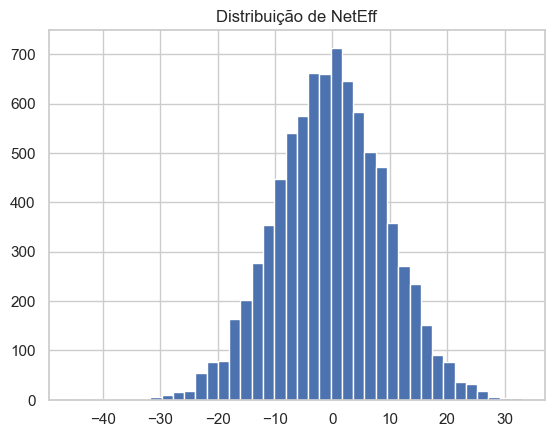

In [17]:
if "NetEff" in team_features.columns:
    team_features["NetEff"].hist(bins=40)
    plt.title("Distribuição de NetEff")
    plt.show()

### Massey Ordinals

In [18]:
massey_df = load_massey_ordinals()
print(massey_df.shape)
massey_df.head()

   Massey: usando 15 sistemas: ['POM', 'SAG', 'MOR', 'COL', 'DOL', 'WLK', 'ARG', 'BPI', 'RPI', 'KPI', 'RTH', 'DCI', 'REW', 'AP', 'USA']
(8355, 17)


,Season,TeamID,Massey_AP,Massey_ARG,Massey_BPI,Massey_COL,Massey_DCI,Massey_DOL,Massey_KPI,Massey_MOR,Massey_POM,Massey_REW,Massey_RPI,Massey_RTH,Massey_SAG,Massey_USA,Massey_WLK
0,2003,1102,NaN,141.0,NaN,162.0,NaN,175.0,NaN,132.0,160.0,NaN,158.0,146.0,149.0,NaN,165.0
1,2003,1103,NaN,180.0,NaN,172.0,NaN,174.0,NaN,139.0,163.0,NaN,182.0,168.0,172.0,NaN,172.0
2,2003,1104,22.0,37.0,NaN,43.0,NaN,39.0,NaN,26.0,33.0,NaN,38.0,31.0,37.0,20.0,36.0
3,2003,1105,NaN,307.0,NaN,310.0,NaN,315.0,NaN,309.0,307.0,NaN,313.0,312.0,312.0,NaN,310.0
4,2003,1106,NaN,252.0,NaN,256.0,NaN,266.0,NaN,294.0,263.0,NaN,248.0,274.0,268.0,NaN,254.0


In [19]:
massey_cols = [c for c in massey_df.columns if c.startswith("Massey_")]
print("Qtd sistemas:", len(massey_cols))
massey_df[massey_cols].isna().mean().sort_values().head(10)

Qtd sistemas: 15


Massey_MOR    0.000000
Massey_POM    0.000359
Massey_WLK    0.001556
Massey_DOL    0.001676
Massey_COL    0.001915
Massey_RTH    0.042729
Massey_SAG    0.130580
Massey_RPI    0.170916
Massey_REW    0.199042
Massey_DCI    0.239497
dtype: float64

### Análise de histórico de torneio

In [20]:
tourney_history = compute_tourney_history(tourney)
tourney_history.head()

,Season,TeamID,HistTourneyWins
0,2019,1101,0
1,2021,1101,0
2,2004,1102,0
3,2006,1102,0
4,1986,1103,0


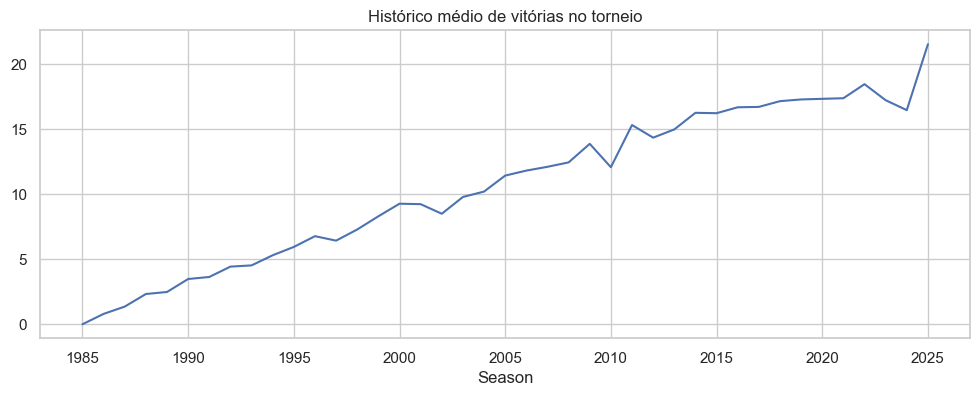

In [21]:
tourney_history.groupby("Season")["HistTourneyWins"].mean().plot(figsize=(12,4), title="Histórico médio de vitórias no torneio")
plt.show()

### Dataset final de treino: inspeção das features

In [22]:
train_matchups = build_training_matchups(
    tourney=tourney,
    team_features=team_features.merge(elo_pre_tourney, on=["Season", "TeamID"], how="left"),
    seeds=seeds,
    elo_df=elo_df,
    tourney_history=tourney_history,
    massey_df=massey_df,
)

feature_cols = get_feature_columns(train_matchups)

print("Shape:", train_matchups.shape)
print("Features:", len(feature_cols))
feature_cols[:20]

Shape: (2585, 160)
Features: 156


['A_Wins',
 'A_Games',
 'A_Score_mean',
 'A_OppScore_mean',
 'A_ScoreDiff_mean',
 'A_OffEff_mean',
 'A_DefEff_mean',
 'A_FGM_mean',
 'A_FGA_mean',
 'A_FGM3_mean',
 'A_FGA3_mean',
 'A_FTM_mean',
 'A_FTA_mean',
 'A_OR_mean',
 'A_DR_mean',
 'A_Ast_mean',
 'A_TO_mean',
 'A_Stl_mean',
 'A_Blk_mean',
 'A_PF_mean']

In [23]:
corrs = train_matchups[feature_cols + ["Result"]].corr(numeric_only=True)["Result"].sort_values(ascending=False)
corrs.head(20)

Result                  1.000000
Diff_ELO                0.472611
B_Seed                  0.376577
Diff_ELO_PreTourney     0.358996
Diff_HistTourneyWins    0.316879
Diff_ScoreDiff_mean     0.302471
Diff_AvgScoreDiff       0.302471
Diff_NetEff             0.299887
Diff_AdjOffEff          0.284978
Diff_Wins               0.277617
Diff_SOS                0.272090
Diff_OffEff_mean        0.246297
Diff_WinPct             0.243653
A_HistTourneyWins       0.218309
Diff_FGM_mean           0.192478
Diff_AstTO              0.186949
Diff_Games              0.178873
Diff_Score_mean         0.172015
B_Massey_MOR            0.170437
B_Massey_RTH            0.167959
Name: Result, dtype: float64

In [24]:
corrs.tail(20)

A_Massey_RTH      -0.224132
A_Massey_COL      -0.228299
A_Massey_DOL      -0.230493
A_Massey_SAG      -0.232263
A_Massey_WLK      -0.232798
A_Massey_POM      -0.233523
Diff_Massey_ARG   -0.234082
A_Massey_MOR      -0.236721
Diff_Massey_REW   -0.266583
Diff_Massey_DCI   -0.275814
Diff_Massey_RPI   -0.308620
Diff_Massey_SAG   -0.322307
Diff_Massey_COL   -0.326415
Diff_Massey_DOL   -0.330608
Diff_Massey_RTH   -0.331202
Diff_Massey_POM   -0.337745
Diff_Massey_WLK   -0.339120
Diff_Massey_MOR   -0.341009
A_Seed            -0.421450
Diff_Seed         -0.492286
Name: Result, dtype: float64

### Visualização das principais variáveis

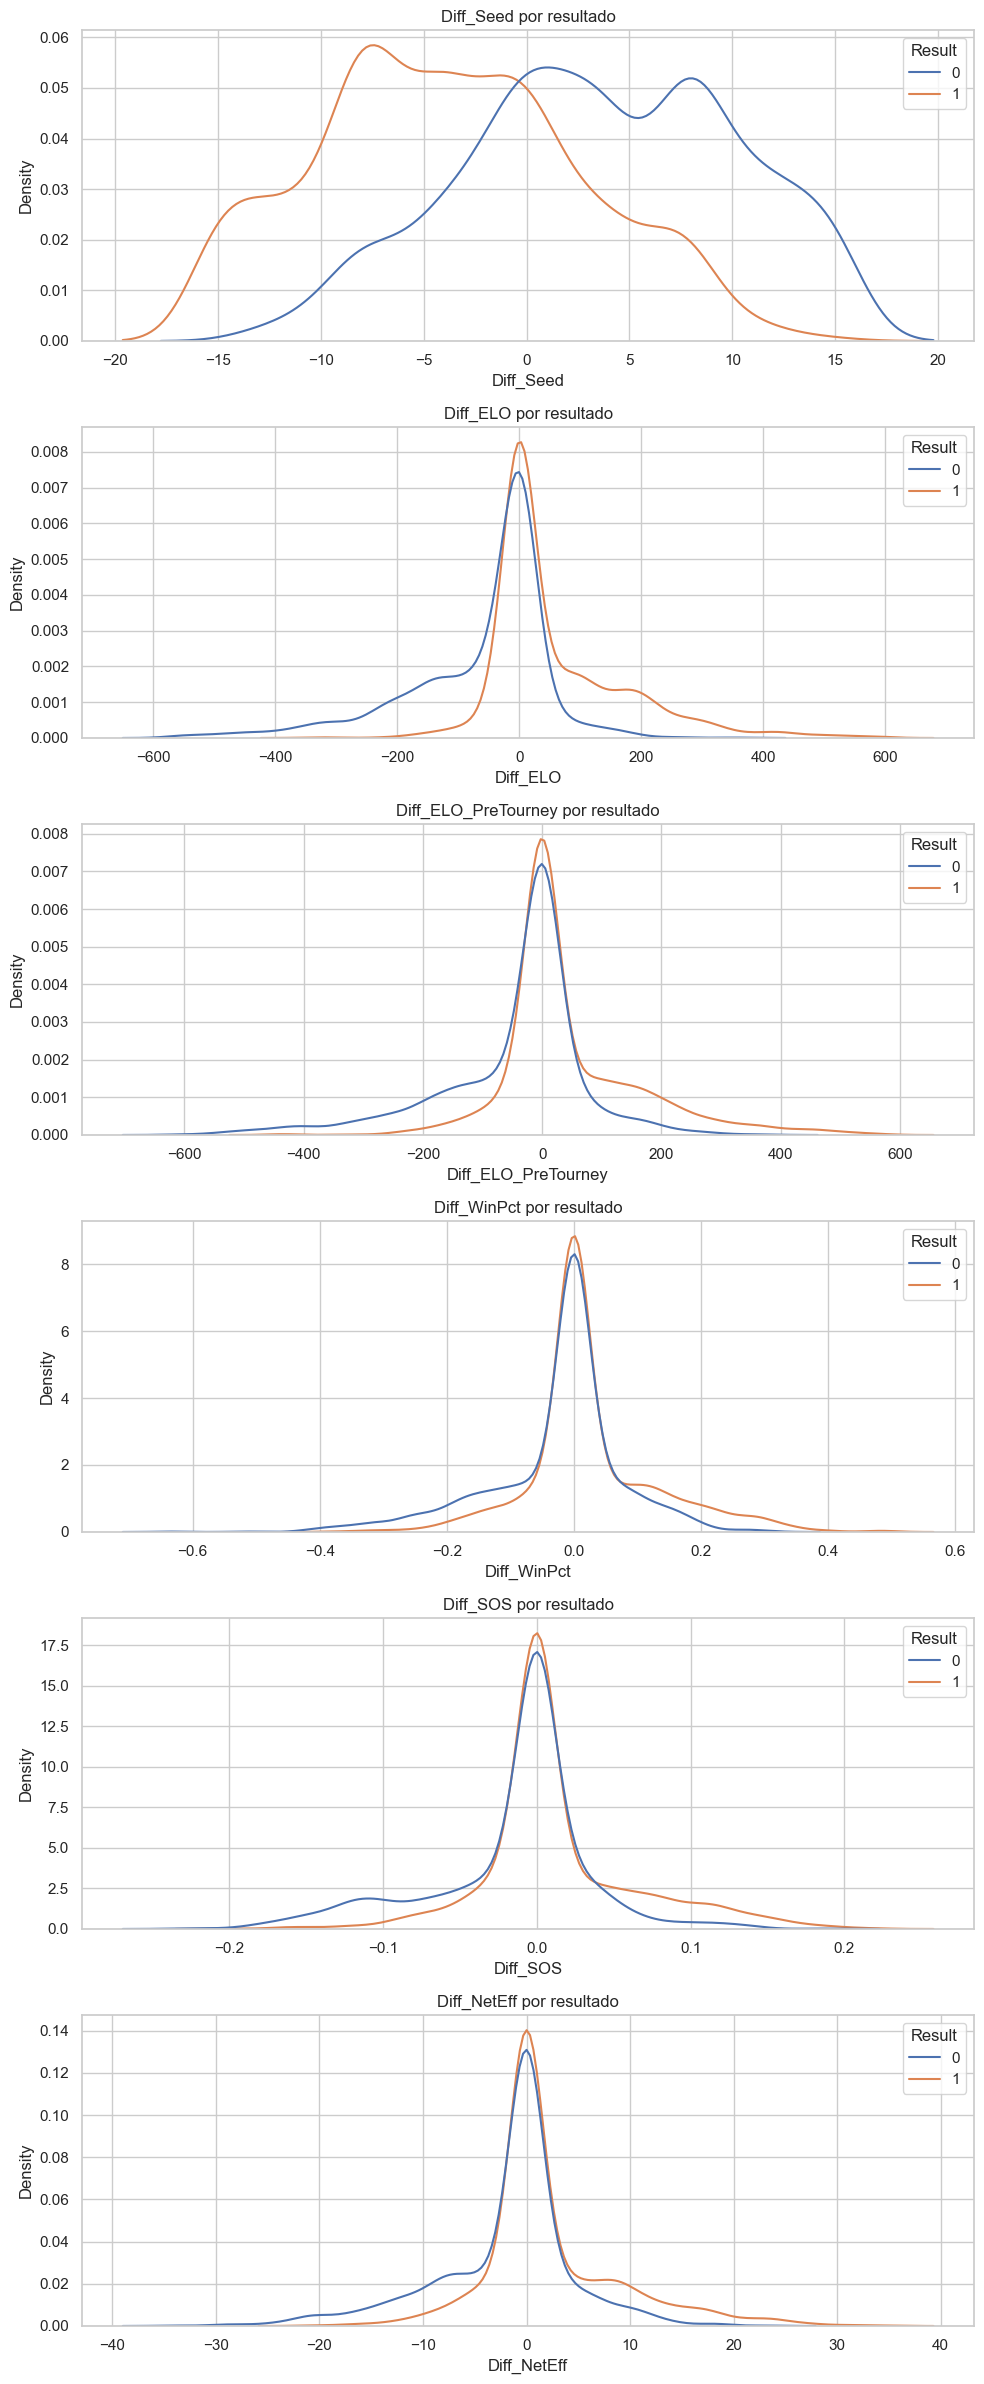

In [25]:
top_vars = [
    "Diff_Seed",
    "Diff_ELO",
    "Diff_ELO_PreTourney",
    "Diff_WinPct",
    "Diff_SOS",
    "Diff_NetEff",
]
top_vars = [c for c in top_vars if c in train_matchups.columns]

fig, axes = plt.subplots(len(top_vars), 1, figsize=(10, 4 * len(top_vars)))
if len(top_vars) == 1:
    axes = [axes]

for ax, col in zip(axes, top_vars):
    sns.kdeplot(data=train_matchups, x=col, hue="Result", common_norm=False, ax=ax)
    ax.set_title(f"{col} por resultado")
plt.tight_layout()
plt.show()

### Missing values

In [28]:
missing = train_matchups.isna().mean().sort_values(ascending=False)
missing[missing > 0].head(30)

Series([], dtype: float64)

### Conclusões do EDA

- Seeds e ELO tendem a ser fortes sinais preditivos;
- Diferenças entre times funcionam melhor do que valores absolutos;
- Features temporais e de forma recente ajudam a capturar contexto;
- Histórico de torneio e Massey Ordinals complementam bem o baseline;
- A validação temporal é essencial para evitar leakage.